# Japanese Equity Data - Feature Engineering

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import talib

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("white")

In [4]:
idx = pd.IndexSlice

## Get Data

### Stooq Japanese Equity data 2014-2019

In [5]:
DATA_DIR = Path("..", "data")

In [6]:
prices = (
    pd.read_hdf(DATA_DIR / "assets.h5", "stooq/jp/tse/stocks/prices")
    .loc[idx[:, "2010":"2019"], :]
    .loc[lambda df: ~df.index.duplicated(), :]
)

In [7]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 6764637 entries, ('1301.JP', Timestamp('2010-01-04 00:00:00')) to ('9997.JP', Timestamp('2019-12-30 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   open    6764637 non-null  float64
 1   high    6764637 non-null  float64
 2   low     6764637 non-null  float64
 3   close   6764637 non-null  float64
 4   volume  6764637 non-null  float64
dtypes: float64(5)
memory usage: 284.2+ MB


In [8]:
before = len(prices.index.unique("ticker").unique())

### Remove symbols with missing values

In [9]:
prices = (
    prices.unstack("ticker")
    .sort_index()
    .ffill(limit=5)
    .dropna(axis=1)
    .stack("ticker")
    .swaplevel()
)
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 5054736 entries, ('1301.JP', Timestamp('2010-01-04 00:00:00')) to ('9997.JP', Timestamp('2019-12-30 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   open    5054736 non-null  float64
 1   high    5054736 non-null  float64
 2   low     5054736 non-null  float64
 3   close   5054736 non-null  float64
 4   volume  5054736 non-null  float64
dtypes: float64(5)
memory usage: 212.3+ MB


In [10]:
after = len(prices.index.unique("ticker").unique())
print(f"Before: {before:,.0f} after: {after:,.0f}")

Before: 3,294 after: 2,064


### Keep most traded symbols

In [11]:
dv = prices.close.mul(prices.volume)
keep = dv.groupby("ticker").median().nlargest(1000).index.tolist()

In [12]:
prices = prices.loc[idx[keep, :], :]
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2449000 entries, ('9984.JP', Timestamp('2010-01-04 00:00:00')) to ('6490.JP', Timestamp('2019-12-30 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   open    2449000 non-null  float64
 1   high    2449000 non-null  float64
 2   low     2449000 non-null  float64
 3   close   2449000 non-null  float64
 4   volume  2449000 non-null  float64
dtypes: float64(5)
memory usage: 103.0+ MB


## Feature Engineering

### Compute period returns

In [13]:
intervals = [1, 5, 10, 21, 63]

In [14]:
returns = []
by_ticker = prices.groupby(level="ticker").close
for t in intervals:
    returns.append(by_ticker.pct_change(t).to_frame(f"ret_{t}"))
returns = pd.concat(returns, axis=1)

In [15]:
returns.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2449000 entries, ('9984.JP', Timestamp('2010-01-04 00:00:00')) to ('6490.JP', Timestamp('2019-12-30 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   ret_1   2448000 non-null  float64
 1   ret_5   2444000 non-null  float64
 2   ret_10  2439000 non-null  float64
 3   ret_21  2428000 non-null  float64
 4   ret_63  2386000 non-null  float64
dtypes: float64(5)
memory usage: 103.0+ MB


### Remove outliers

In [16]:
max_ret_by_sym = returns.groupby(level="ticker").max()

In [17]:
percentiles = [0.001, 0.005, 0.01, 0.025, 0.05, 0.1]
percentiles += [1 - p for p in percentiles]
max_ret_by_sym.describe(percentiles=sorted(percentiles)[6:])

,ret_1,ret_5,ret_10,ret_21,ret_63
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.173832,0.361172,0.485816,0.649057,1.036371
std,0.088685,0.317434,0.545981,0.869540,1.499520
min,0.066820,0.105317,0.106827,0.130858,0.204475
50%,0.151412,0.256993,0.311170,0.394192,0.654482
90%,0.278768,0.634377,0.861898,1.097518,1.787867
95%,0.349422,1.000002,1.435301,1.797241,2.836706
97.5%,0.386164,1.402429,2.154763,3.341897,4.641381
99%,0.471818,1.668682,3.300743,4.935302,7.872836
99.5%,0.600000,2.059154,3.590282,6.075514,9.316707


In [18]:
quantiles = max_ret_by_sym.quantile(0.95)
to_drop = []
for ret, q in quantiles.items():
    to_drop.extend(max_ret_by_sym[max_ret_by_sym[ret] > q].index.tolist())

In [19]:
to_drop = pd.Series(to_drop).value_counts()
to_drop = to_drop[to_drop > 1].index.tolist()
len(to_drop)

55

In [20]:
prices = prices.drop(to_drop, level="ticker")
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2314305 entries, ('9984.JP', Timestamp('2010-01-04 00:00:00')) to ('6490.JP', Timestamp('2019-12-30 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   open    2314305 non-null  float64
 1   high    2314305 non-null  float64
 2   low     2314305 non-null  float64
 3   close   2314305 non-null  float64
 4   volume  2314305 non-null  float64
dtypes: float64(5)
memory usage: 97.3+ MB


### Calculate relative return percentiles

In [22]:
returns = []
by_sym = prices.groupby(level="ticker").close
for t in intervals:
    ret = by_sym.pct_change(t)
    rel_perc = ret.groupby(level="date").transform(
        lambda x: pd.qcut(x, q=20, labels=False, duplicates="drop")
    )
    returns.extend([ret.to_frame(f"ret_{t}"), rel_perc.to_frame(f"ret_rel_perc_{t}")])
returns = pd.concat(returns, axis=1)

### Technical Indicators

#### Percentage Price Oscillator

In [30]:
ppo = prices.groupby(level="ticker").close.transform(talib.PPO).to_frame("PPO")

#### Normalized Average True Range

In [33]:
natr = (
    prices.groupby(level="ticker", group_keys=False)
    .apply(lambda x: talib.NATR(x.high, x.low, x.close))
    .to_frame("NATR")
)

#### Relative Strength Indicator

In [36]:
rsi = prices.groupby(level="ticker").close.transform(talib.RSI).to_frame("RSI")

#### Bollinger Bands

In [26]:
def get_bollinger(x):
    u, m, l = talib.BBANDS(x)
    return pd.DataFrame({"u": u, "m": m, "l": l})

In [39]:
bbands = prices.groupby(level="ticker").close.apply(get_bollinger)

In [42]:
bbands = bbands.droplevel(1)

### Combine Features

In [43]:
data = pd.concat([prices, returns, ppo, natr, rsi, bbands], axis=1)

In [44]:
data["bbl"] = data.close.div(data.l)
data["bbu"] = data.u.div(data.close)
data = data.drop(["u", "m", "l"], axis=1)

In [45]:
data.bbu.corr(data.bbl, method="spearman")

-0.15617160017067147

### Plot Indicators for randomly sample ticker

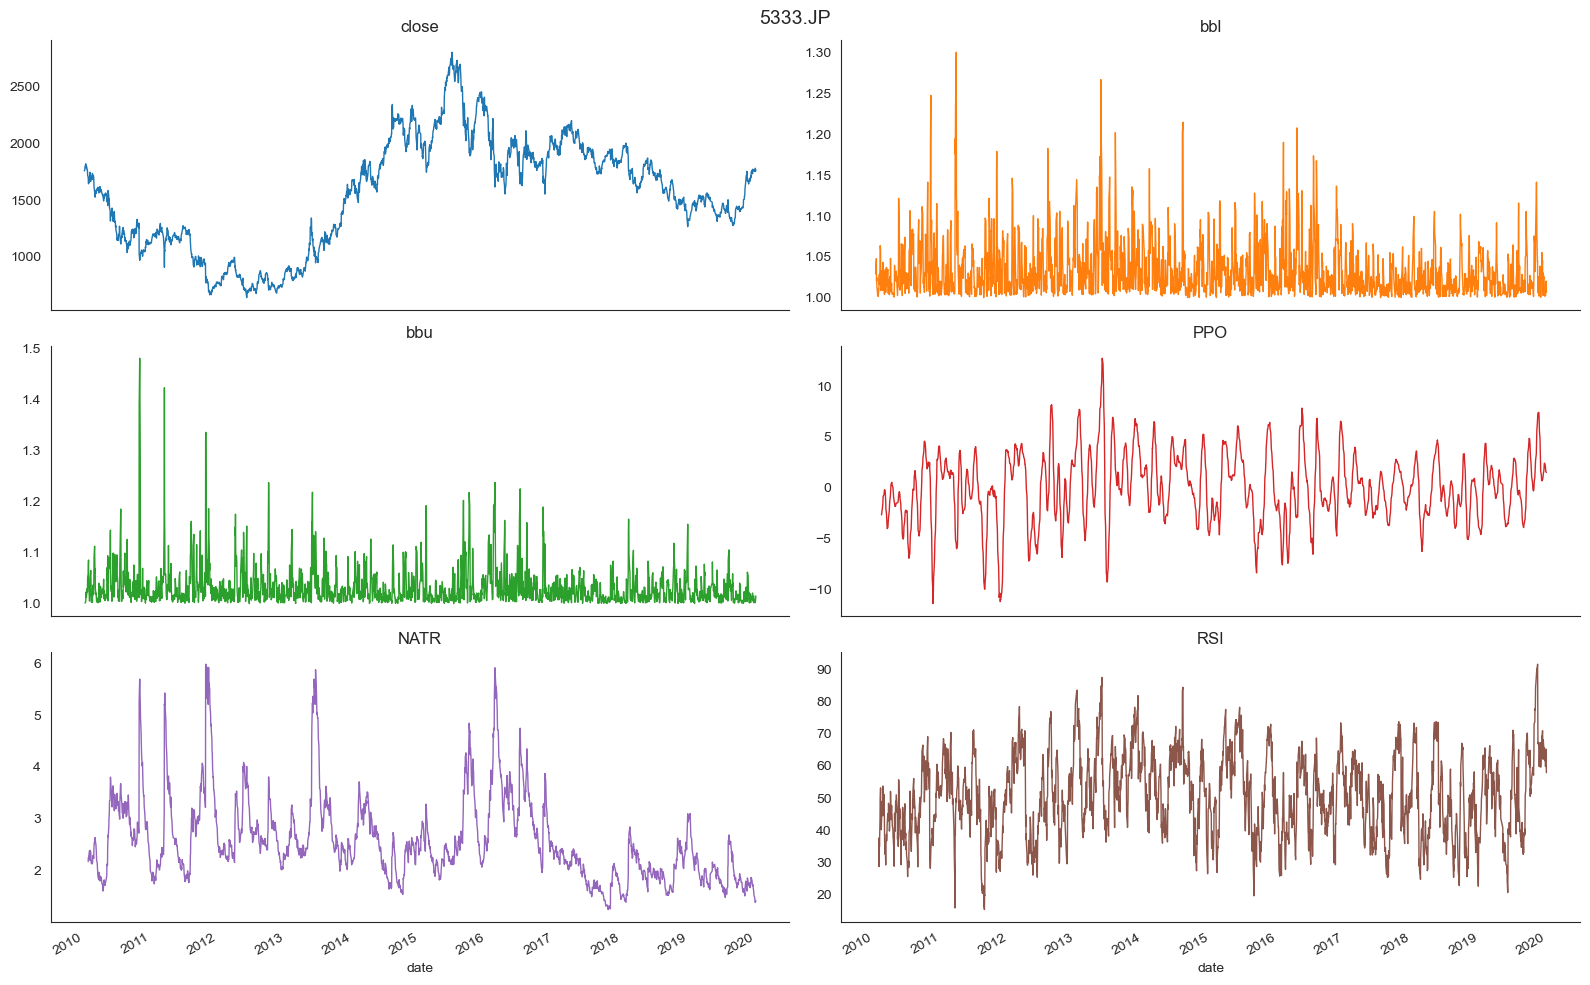

In [46]:
indicators = ["close", "bbl", "bbu", "PPO", "NATR", "RSI"]
ticker = np.random.choice(data.index.get_level_values("ticker"))
(
    data.loc[idx[ticker, :], indicators]
    .reset_index("ticker", drop=True)
    .plot(
        lw=1,
        subplots=True,
        figsize=(16, 10),
        title=indicators,
        layout=(3, 2),
        legend=False,
    )
)
plt.suptitle(ticker, fontsize=14)
sns.despine()
plt.tight_layout()
plt.subplots_adjust(top=0.95)

In [47]:
data = data.drop(prices.columns, axis=1)

### Create time period indicators

In [48]:
dates = data.index.get_level_values("date")
data["weekday"] = dates.weekday
data["month"] = dates.month
data["year"] = dates.year

## Compute forward returns

In [49]:
outcomes = []
by_ticker = data.groupby("ticker")
for t in intervals:
    k = f"fwd_ret_{t:02}"
    outcomes.append(k)
    data[k] = by_ticker[f"ret_{t}"].shift(-t)

In [50]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2314305 entries, ('9984.JP', Timestamp('2010-01-04 00:00:00')) to ('6490.JP', Timestamp('2019-12-30 00:00:00'))
Data columns (total 23 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   ret_1            2313360 non-null  float64
 1   ret_rel_perc_1   2313360 non-null  float64
 2   ret_5            2309580 non-null  float64
 3   ret_rel_perc_5   2309580 non-null  float64
 4   ret_10           2304855 non-null  float64
 5   ret_rel_perc_10  2304855 non-null  float64
 6   ret_21           2294460 non-null  float64
 7   ret_rel_perc_21  2294460 non-null  float64
 8   ret_63           2254770 non-null  float64
 9   ret_rel_perc_63  2254770 non-null  float64
 10  PPO              2290680 non-null  float64
 11  NATR             2301075 non-null  float64
 12  RSI              2301075 non-null  float64
 13  bbl              2310525 non-null  float64
 14  bbu              2310525 non-nul

In [51]:
data.to_hdf("data.h5", "stooq/japan/equities")